# 01 DA Prices Cleaning Walkthrough

This notebook follows the shared DA prices cleaning pipeline in `scripts/Data/01_cleaning/day_ahead_prices_pipeline.py`.

It shows:

- how the raw XML files are parsed
- the main intermediate cleaning stages
- the upstream missing-datapoint fix
- the final cleaned hourly and quarter-hourly outputs

This is the upstream cleaning stage for the forecasting notebooks:

- raw missing-datapoint handling belongs here
- later forecasting notebooks treat the cleaned target series as fixed
- if a later notebook builds a causal helper series, that is only for leakage-safe feature construction and does **not** overwrite the cleaned target

The active rule is:

- interpolate only real missing datapoints on the canonical UTC grid
- do not treat DST as a missing-data problem, because the source timestamps are already UTC
- if more than two consecutive datapoints are missing, flag them and leave them missing


In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path
from typing import Any

import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current notebook directory.")


REPO_ROOT = find_repo_root()


def load_cleaning_module():
    module_path = REPO_ROOT / "scripts" / "Data" / "01_cleaning" / "day_ahead_prices_pipeline.py"
    spec = importlib.util.spec_from_file_location("day_ahead_prices_pipeline_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


cleaning = load_cleaning_module()


In [2]:
REGIONS = ["BE", "DE", "NL"]
FOCUS_REGION = "NL"
MARKET_TIMEZONES = {
    "BE": "Europe/Brussels",
    "DE": "Europe/Berlin",
    "NL": "Europe/Amsterdam",
}

RAW_ROOT = REPO_ROOT / "data" / "00_Raw" / "DA_Prices"
OUTPUT_ROOT = REPO_ROOT / "data" / "01_cleaned" / "Day_ahead_prices"
CUTOFF_LOCAL_DATE = "2025-10-01"
LOCAL_TIMEZONE = "Europe/Brussels"
MAX_TIMESTAMP_UTC = pd.Timestamp("2026-01-01T00:00:00Z")

CUTOFF_LOCAL = pd.Timestamp(CUTOFF_LOCAL_DATE).tz_localize(LOCAL_TIMEZONE)
CUTOFF_UTC = CUTOFF_LOCAL.tz_convert("UTC")

config_df = pd.DataFrame(
    [
        {"setting": "Raw root", "value": str(RAW_ROOT)},
        {"setting": "Output root", "value": str(OUTPUT_ROOT)},
        {"setting": "Regions", "value": ", ".join(REGIONS)},
        {"setting": "Focus region", "value": FOCUS_REGION},
        {"setting": "Cutoff local date", "value": CUTOFF_LOCAL_DATE},
        {"setting": "Cutoff UTC", "value": CUTOFF_UTC.isoformat()},
        {"setting": "Max timestamp UTC", "value": MAX_TIMESTAMP_UTC.isoformat()},
    ]
)
display(config_df)


,setting,value
0,Raw root,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices
1,Output root,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Day_ahead_prices
2,Regions,"BE, DE, NL"
3,Focus region,NL
4,Cutoff local date,2025-10-01
5,Cutoff UTC,2025-09-30T22:00:00+00:00
6,Max timestamp UTC,2026-01-01T00:00:00+00:00


## Notebook Helpers

These helpers intentionally reuse the same parsing, deduplication, clipping, and missing-datapoint interpolation logic as the shared cleaning script.


In [3]:
def build_region_result(region: str) -> dict[str, Any]:
    xml_files = sorted((RAW_ROOT / f"DA_prices_{region}").rglob("*.xml"))
    rows: list[dict[str, Any]] = []
    file_summaries: list[dict[str, Any]] = []
    parse_errors: list[dict[str, Any]] = []

    for xml_file in xml_files:
        try:
            file_rows, file_summary = cleaning.parse_single_xml(region, xml_file)
        except Exception as exc:  # noqa: BLE001
            parse_errors.append(
                {
                    "region": region,
                    "source_path": str(xml_file),
                    "error": str(exc),
                }
            )
            continue
        rows.extend(file_rows)
        file_summaries.append(file_summary)

    df_raw = cleaning.make_region_dataframe(rows)
    df_after_sequence_filter = df_raw.copy()
    sequence_2_rows_removed = 0
    if region == "DE" and not df_after_sequence_filter.empty:
        mask_seq2 = df_after_sequence_filter["timeseries_sequence_position"] == 2
        sequence_2_rows_removed = int(mask_seq2.sum())
        df_after_sequence_filter = df_after_sequence_filter[~mask_seq2].copy()

    df_after_dedup_clip, duplicate_rows_removed = cleaning.split_duplicate_stats(df_after_sequence_filter)
    df_after_dedup_clip = cleaning.clip_to_max_timestamp(
        df_after_dedup_clip,
        max_timestamp_utc=MAX_TIMESTAMP_UTC,
    )

    pre_cutoff = df_after_dedup_clip[df_after_dedup_clip["timestamp_utc"] < CUTOFF_UTC].copy()
    post_cutoff = df_after_dedup_clip[df_after_dedup_clip["timestamp_utc"] >= CUTOFF_UTC].copy()

    hourly_before_fix = pre_cutoff[pre_cutoff["resolution_minutes"] == 60].copy()
    quarterly_before_fix = post_cutoff[post_cutoff["resolution_minutes"] == 15].copy()

    timezone = MARKET_TIMEZONES.get(region, LOCAL_TIMEZONE)
    hourly_fix = cleaning.apply_missing_datapoint_fix(
        hourly_before_fix,
        expected_minutes=60,
        dataset="hourly",
        local_timezone=timezone,
    )
    quarterly_fix = cleaning.apply_missing_datapoint_fix(
        quarterly_before_fix,
        expected_minutes=15,
        dataset="quarterly",
        local_timezone=timezone,
    )

    other_rows = df_after_dedup_clip.copy()
    hourly_scope_mask = (other_rows["timestamp_utc"] < CUTOFF_UTC) & (other_rows["resolution_minutes"] == 60)
    quarterly_scope_mask = (other_rows["timestamp_utc"] >= CUTOFF_UTC) & (other_rows["resolution_minutes"] == 15)
    other_rows = other_rows[~hourly_scope_mask & ~quarterly_scope_mask].copy()

    final_frames = [frame for frame in [other_rows, hourly_fix.cleaned_frame, quarterly_fix.cleaned_frame] if not frame.empty]
    final_aggregated = (
        pd.concat(final_frames, ignore_index=True).sort_values("timestamp_utc").reset_index(drop=True)
        if final_frames
        else pd.DataFrame()
    )

    return {
        "region": region,
        "xml_files": xml_files,
        "file_summary_df": pd.DataFrame(file_summaries),
        "parse_errors_df": pd.DataFrame(parse_errors),
        "df_raw": df_raw,
        "df_after_sequence_filter": df_after_sequence_filter,
        "df_after_dedup_clip": df_after_dedup_clip,
        "hourly_before_fix": hourly_before_fix,
        "quarterly_before_fix": quarterly_before_fix,
        "hourly_fix": hourly_fix,
        "quarterly_fix": quarterly_fix,
        "hourly_final": hourly_fix.cleaned_frame,
        "quarterly_final": quarterly_fix.cleaned_frame,
        "final_aggregated": final_aggregated,
        "duplicate_rows_removed": duplicate_rows_removed,
        "sequence_2_rows_removed": sequence_2_rows_removed,
    }


def summarize_stage(region: str, stage_name: str, df: pd.DataFrame, expected_minutes: int | None = None) -> dict[str, Any]:
    if df.empty:
        return {
            "region": region,
            "stage": stage_name,
            "rows": 0,
            "min_timestamp_utc": None,
            "max_timestamp_utc": None,
            "duplicate_timestamps": 0,
            "missing_timestamps": 0,
            "missing_price_points": 0,
            "interpolated_points": 0,
        }

    timestamps = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
    return {
        "region": region,
        "stage": stage_name,
        "rows": int(df.shape[0]),
        "min_timestamp_utc": timestamps.min().isoformat(),
        "max_timestamp_utc": timestamps.max().isoformat(),
        "duplicate_timestamps": int(timestamps.duplicated().sum()),
        "missing_timestamps": cleaning.missing_timestamps(df, expected_minutes),
        "missing_price_points": int(pd.to_numeric(df["price_eur_per_mwh"], errors="coerce").isna().sum()),
        "interpolated_points": int(df["is_interpolated_value"].sum()) if "is_interpolated_value" in df.columns else 0,
    }


In [4]:
def build_stage_summary(region_results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for region, result in region_results.items():
        rows.extend(
            [
                summarize_stage(region, "raw_parsed", result["df_raw"], None),
                summarize_stage(region, "after_sequence_filter", result["df_after_sequence_filter"], None),
                summarize_stage(region, "after_dedup_clip", result["df_after_dedup_clip"], None),
                summarize_stage(region, "hourly_before_fix", result["hourly_before_fix"], 60),
                summarize_stage(region, "hourly_after_fix", result["hourly_final"], 60),
                summarize_stage(region, "quarterly_before_fix", result["quarterly_before_fix"], 15),
                summarize_stage(region, "quarterly_after_fix", result["quarterly_final"], 15),
            ]
        )
    return pd.DataFrame(rows)


def build_final_diagnostics(region_results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for region, result in region_results.items():
        rows.append(
            cleaning.stats_row(
                region=region,
                dataset="aggregated",
                df=result["final_aggregated"],
                duplicate_rows_removed=result["duplicate_rows_removed"],
                sequence_2_rows_removed=result["sequence_2_rows_removed"],
            )
        )
        rows.append(
            cleaning.stats_row(
                region=region,
                dataset="hourly",
                df=result["hourly_final"],
                gap_fix_summary=result["hourly_fix"].summary,
                missing_timestamps_count_override=result["hourly_fix"].summary["missing_timestamps_before_fix"],
            )
        )
        rows.append(
            cleaning.stats_row(
                region=region,
                dataset="quarterly",
                df=result["quarterly_final"],
                gap_fix_summary=result["quarterly_fix"].summary,
                missing_timestamps_count_override=result["quarterly_fix"].summary["missing_timestamps_before_fix"],
            )
        )
    return pd.DataFrame(rows).sort_values(["dataset", "region"]).reset_index(drop=True)


def combine_gap_fix_summaries(region_results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for result in region_results.values():
        rows.append(result["hourly_fix"].summary)
        rows.append(result["quarterly_fix"].summary)
    return pd.DataFrame(rows).sort_values(["dataset", "region"]).reset_index(drop=True)


def combine_gap_fix_details(region_results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    frames = []
    for result in region_results.values():
        if not result["hourly_fix"].gap_details.empty:
            frames.append(result["hourly_fix"].gap_details)
        if not result["quarterly_fix"].gap_details.empty:
            frames.append(result["quarterly_fix"].gap_details)
    if not frames:
        return cleaning.empty_gap_details_frame()
    return pd.concat(frames, ignore_index=True).sort_values(["dataset", "region", "gap_start_utc"]).reset_index(drop=True)


def build_source_coverage(region_results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for region, result in region_results.items():
        file_summary_df = result["file_summary_df"]
        rows.append(
            {
                "region": region,
                "xml_files": int(len(result["xml_files"])),
                "parsed_rows": int(result["df_raw"].shape[0]),
                "min_doc_period_start_utc": file_summary_df["doc_period_start_utc"].min() if not file_summary_df.empty else None,
                "max_doc_period_end_utc": file_summary_df["doc_period_end_utc"].max() if not file_summary_df.empty else None,
                "parsed_timestamp_dtype": str(result["df_raw"]["timestamp_utc"].dtype) if not result["df_raw"].empty else None,
                "parsed_tz": str(result["df_raw"]["timestamp_utc"].dt.tz) if not result["df_raw"].empty else None,
            }
        )
    return pd.DataFrame(rows).sort_values("region").reset_index(drop=True)


def build_cleaning_delta_table(region_results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for region, result in region_results.items():
        rows.append(
            {
                "region": region,
                "sequence_2_rows_removed": result["sequence_2_rows_removed"],
                "duplicate_rows_removed": result["duplicate_rows_removed"],
                "rows_after_dedup_clip": int(result["df_after_dedup_clip"].shape[0]),
                "hourly_rows_before_fix": int(result["hourly_before_fix"].shape[0]),
                "hourly_rows_after_fix": int(result["hourly_final"].shape[0]),
                "quarterly_rows_before_fix": int(result["quarterly_before_fix"].shape[0]),
                "quarterly_rows_after_fix": int(result["quarterly_final"].shape[0]),
            }
        )
    return pd.DataFrame(rows).sort_values("region").reset_index(drop=True)


In [5]:
def plot_stage_row_counts(stage_summary_df: pd.DataFrame) -> None:
    stage_order = [
        "raw_parsed",
        "after_sequence_filter",
        "after_dedup_clip",
        "hourly_before_fix",
        "hourly_after_fix",
        "quarterly_before_fix",
        "quarterly_after_fix",
    ]
    pivot = stage_summary_df.pivot(index="stage", columns="region", values="rows").reindex(stage_order)
    ax = pivot.plot(kind="bar", figsize=(13, 5), width=0.82)
    ax.set_title("Rows by cleaning stage")
    ax.set_xlabel("Stage")
    ax.set_ylabel("Rows")
    ax.legend(title="Region")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_gap_fix_summary(gap_fix_summary_df: pd.DataFrame) -> None:
    work = gap_fix_summary_df.copy()
    work["label"] = work["region"] + " " + work["dataset"]
    ax = work.set_index("label")[
        [
            "missing_datapoints_before_fix",
            "interpolated_points_count",
            "remaining_missing_points_after_fix",
        ]
    ].plot(kind="bar", figsize=(13, 5), width=0.82)
    ax.set_title("Missing datapoints before and after the interpolation fix")
    ax.set_xlabel("Region and dataset")
    ax.set_ylabel("Datapoints")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_daily_means(region_results: dict[str, dict[str, Any]], dataset: str) -> None:
    key = "hourly_final" if dataset == "hourly" else "quarterly_final"
    fig, ax = plt.subplots(figsize=(14, 5))
    for region in REGIONS:
        frame = region_results[region][key].copy()
        if frame.empty:
            continue
        series = (
            frame.dropna(subset=["price_eur_per_mwh"])
            .set_index("timestamp_utc")["price_eur_per_mwh"]
            .sort_index()
            .resample("D")
            .mean()
        )
        ax.plot(series.index, series.values, linewidth=1.3, label=region)
    ax.set_title(f"Final cleaned {dataset} series | daily mean prices")
    ax.set_xlabel("UTC date")
    ax.set_ylabel("EUR/MWh")
    ax.legend(title="Region")
    plt.tight_layout()
    plt.show()


In [6]:
def plot_gap_windows(region_result: dict[str, Any], dataset: str, action: str, max_windows: int = 3) -> None:
    fix = region_result["hourly_fix"] if dataset == "hourly" else region_result["quarterly_fix"]
    raw = region_result["hourly_before_fix"] if dataset == "hourly" else region_result["quarterly_before_fix"]
    candidates = fix.gap_details[fix.gap_details["action"] == action].copy()
    if candidates.empty:
        print(f"No gaps with action='{action}' for {region_result['region']} {dataset}.")
        return

    candidates["gap_start_utc"] = pd.to_datetime(candidates["gap_start_utc"], utc=True)
    candidates["gap_end_utc"] = pd.to_datetime(candidates["gap_end_utc"], utc=True)
    if action == "interpolate":
        candidates = candidates.sort_values("gap_start_utc", ascending=True)
    else:
        candidates = candidates.sort_values(["gap_length_points", "gap_start_utc"], ascending=[False, True])
    candidates = candidates.head(max_windows).reset_index(drop=True)

    pad = pd.Timedelta(hours=24) if dataset == "hourly" else pd.Timedelta(hours=6)
    step = pd.Timedelta(minutes=60 if dataset == "hourly" else 15)
    fig, axes = plt.subplots(len(candidates), 1, figsize=(14, 4 * len(candidates)), sharex=False)
    if len(candidates) == 1:
        axes = [axes]

    for axis, row in zip(axes, candidates.itertuples(index=False)):
        window_start = row.gap_start_utc - pad
        window_end = row.gap_end_utc + pad
        raw_slice = raw[(raw["timestamp_utc"] >= window_start) & (raw["timestamp_utc"] <= window_end)].copy()
        final_slice = fix.cleaned_frame[
            (fix.cleaned_frame["timestamp_utc"] >= window_start) & (fix.cleaned_frame["timestamp_utc"] <= window_end)
        ].copy()

        axis.plot(
            final_slice["timestamp_utc"],
            final_slice["price_eur_per_mwh"],
            color="#005f73",
            linewidth=2.0,
            label="Final cleaned series",
        )
        axis.scatter(
            raw_slice["timestamp_utc"],
            raw_slice["price_eur_per_mwh"],
            color="#6c757d",
            s=30,
            alpha=0.8,
            label="Observed before fix",
        )

        if action == "interpolate":
            highlighted = final_slice[final_slice["gap_fix_action"] == "interpolate"].copy()
            axis.scatter(
                highlighted["timestamp_utc"],
                highlighted["price_eur_per_mwh"],
                color="#bb3e03",
                s=50,
                label="Interpolated points",
                zorder=5,
            )
        else:
            axis.axvspan(row.gap_start_utc, row.gap_end_utc + step, color="#ae2012", alpha=0.18, label="Flagged gap")

        axis.set_title(
            f"{region_result['region']} {dataset} | {action} | "
            f"{row.gap_start_utc.date()} | {row.gap_length_points} datapoints"
        )
        axis.set_xlabel("Timestamp UTC")
        axis.set_ylabel("EUR/MWh")
        handles, labels = axis.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axis.legend(unique.values(), unique.keys(), loc="best")

    plt.tight_layout()
    plt.show()


In [7]:
region_results = {region: build_region_result(region) for region in REGIONS}

source_coverage_df = build_source_coverage(region_results)
cleaning_delta_df = build_cleaning_delta_table(region_results)
stage_summary_df = build_stage_summary(region_results)
gap_fix_summary_df = combine_gap_fix_summaries(region_results)
gap_fix_details_df = combine_gap_fix_details(region_results)
final_diagnostics_df = build_final_diagnostics(region_results)

file_summary_df = pd.concat(
    [result["file_summary_df"] for result in region_results.values() if not result["file_summary_df"].empty],
    ignore_index=True,
)
parse_errors_df = pd.concat(
    [result["parse_errors_df"] for result in region_results.values() if not result["parse_errors_df"].empty],
    ignore_index=True,
) if any(not result["parse_errors_df"].empty for result in region_results.values()) else pd.DataFrame()


## 1. Raw Source Parsing and UTC Verification

The existing cleaner parses the ENTSO-E XML periods with `utc=True`. Because the raw timestamps are explicit UTC timestamps, DST does not create missing UTC observations.


In [8]:
display(source_coverage_df)


,region,xml_files,parsed_rows,min_doc_period_start_utc,max_doc_period_end_utc,parsed_timestamp_dtype,parsed_tz
0,BE,16,41708,2021-12-31T23:00:00+00:00,2026-01-01T23:00:00+00:00,"datetime64[us, UTC]",UTC
1,DE,32,181058,2021-12-31T23:00:00+00:00,2026-01-01T23:00:00+00:00,"datetime64[us, UTC]",UTC
2,NL,16,41610,2021-12-31T23:00:00+00:00,2026-01-01T23:00:00+00:00,"datetime64[us, UTC]",UTC


In [9]:
if not file_summary_df.empty:
    display(file_summary_df.head(10))
else:
    print("No XML file summaries were created.")

if not parse_errors_df.empty:
    display(parse_errors_df)
else:
    display(Markdown("**XML parse errors:** none"))


,region,source_file,source_path,document_id,created_datetime_utc,doc_period_start_utc,doc_period_end_utc,timeseries_count,period_count,point_count,rows_generated,resolution_distribution
0,BE,12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0000.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0000.xml,b256f5750a004b46b3999bc70cfd8686,2026-03-31T14:18:19+00:00,2021-12-31T23:00:00+00:00,2022-04-10T22:00:00+00:00,100,100,2382,2382,"{""PT60M"": 100}"
1,BE,12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0100.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0100.xml,902bcf669d8643fd9594b0182c5c42a8,2026-03-31T14:18:20+00:00,2022-04-10T22:00:00+00:00,2022-07-19T22:00:00+00:00,100,100,2394,2394,"{""PT60M"": 100}"
2,BE,12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0200.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0200.xml,b509de997f4641b78d98f52bc4b9f4c0,2026-03-31T14:18:21+00:00,2022-07-19T22:00:00+00:00,2022-10-27T22:00:00+00:00,100,100,2391,2391,"{""PT60M"": 100}"
3,BE,12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0300.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2022_offset_0300.xml,919b62026e5146ef90fd5fdc6eacd945,2026-03-31T14:18:22+00:00,2022-10-27T22:00:00+00:00,2023-01-01T23:00:00+00:00,66,66,1575,1575,"{""PT60M"": 66}"
4,BE,12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0000.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0000.xml,09430c215bc04507b74f4615015f2af0,2026-03-31T14:18:23+00:00,2022-12-31T23:00:00+00:00,2023-04-10T22:00:00+00:00,100,100,2391,2391,"{""PT60M"": 100}"
5,BE,12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0100.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0100.xml,28b7fd20e8c646888d17c57cc9cbc737,2026-03-31T14:18:24+00:00,2023-04-10T22:00:00+00:00,2023-07-19T22:00:00+00:00,100,100,2394,2394,"{""PT60M"": 100}"
6,BE,12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0200.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0200.xml,307bcb434ded48739223530b816885bb,2026-03-31T14:18:26+00:00,2023-07-19T22:00:00+00:00,2023-10-27T22:00:00+00:00,100,100,2395,2395,"{""PT60M"": 100}"
7,BE,12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0300.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2023_offset_0300.xml,cf12e931ecc04ff1a63e3f9a7c68cc0e,2026-03-31T14:18:27+00:00,2023-10-27T22:00:00+00:00,2024-01-01T23:00:00+00:00,66,66,1580,1580,"{""PT60M"": 66}"
8,BE,12_1_d_energy_prices_a01_day_ahead_BE_2024_offset_0000.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2024_offset_0000.xml,9d0102054803428caea970758cd77077,2026-03-31T14:18:28+00:00,2023-12-31T23:00:00+00:00,2024-04-09T22:00:00+00:00,100,100,2380,2380,"{""PT60M"": 100}"
9,BE,12_1_d_energy_prices_a01_day_ahead_BE_2024_offset_0100.xml,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\DA_Prices\DA_prices_BE\A01_Day_Ahead_Market\12_1_d_energy_prices_a01_day_ahead_BE_2024_offset_0100.xml,9c635d9871794f798e1500f7407a88a5,2026-03-31T14:18:29+00:00,2024-04-09T22:00:00+00:00,2024-07-18T22:00:00+00:00,100,100,2397,2397,"{""PT60M"": 100}"


**XML parse errors:** none

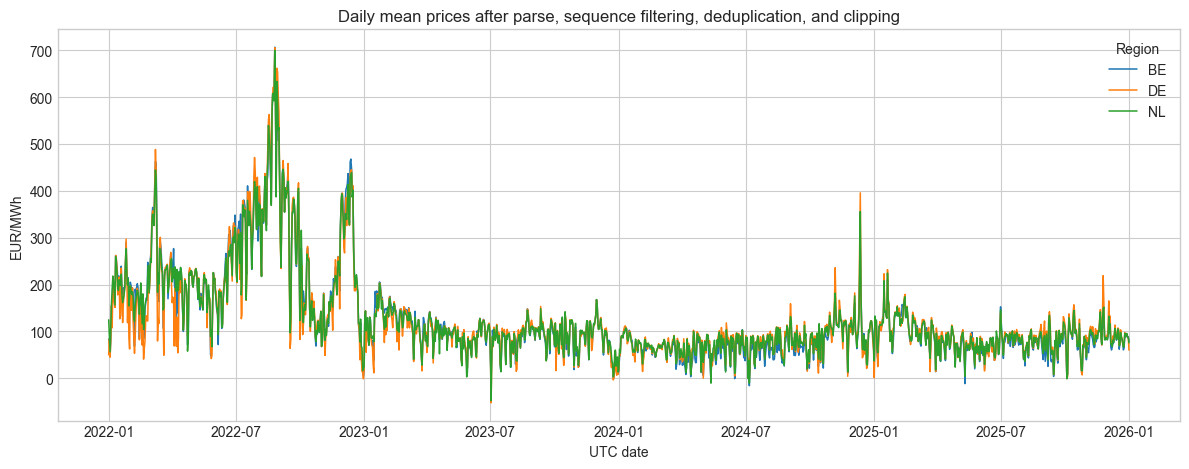

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.8))
for region in REGIONS:
    frame = region_results[region]["df_after_dedup_clip"].copy()
    if frame.empty:
        continue
    series = (
        frame.dropna(subset=["price_eur_per_mwh"])
        .set_index("timestamp_utc")["price_eur_per_mwh"]
        .sort_index()
        .resample("D")
        .mean()
    )
    ax.plot(series.index, series.values, linewidth=1.1, label=region)
ax.set_title("Daily mean prices after parse, sequence filtering, deduplication, and clipping")
ax.set_xlabel("UTC date")
ax.set_ylabel("EUR/MWh")
ax.legend(title="Region")
plt.tight_layout()
plt.show()


## 2. Intermediate Cleaning Stages

This section shows how many rows remain after the main shared cleaning steps, including the special Germany sequence-2 removal and duplicate removal.


In [11]:
display(cleaning_delta_df)
display(stage_summary_df)


,region,sequence_2_rows_removed,duplicate_rows_removed,rows_after_dedup_clip,hourly_rows_before_fix,hourly_rows_after_fix,quarterly_rows_before_fix,quarterly_rows_after_fix
0,BE,0,72,41545,32707,32831,8814,8841
1,DE,139435,68,41487,32702,32855,8785,8841
2,NL,0,69,41452,32660,32855,8792,8841


,region,stage,rows,min_timestamp_utc,max_timestamp_utc,duplicate_timestamps,missing_timestamps,missing_price_points,interpolated_points
0,BE,raw_parsed,41708,2021-12-31T23:00:00+00:00,2026-01-01T22:45:00+00:00,72,0,0,0
1,BE,after_sequence_filter,41708,2021-12-31T23:00:00+00:00,2026-01-01T22:45:00+00:00,72,0,0,0
2,BE,after_dedup_clip,41545,2021-12-31T23:00:00+00:00,2026-01-01T00:00:00+00:00,0,0,0,0
3,BE,hourly_before_fix,32707,2021-12-31T23:00:00+00:00,2025-09-29T21:00:00+00:00,0,124,0,0
4,BE,hourly_after_fix,32831,2021-12-31T23:00:00+00:00,2025-09-29T21:00:00+00:00,0,0,16,108
5,BE,quarterly_before_fix,8814,2025-09-30T22:00:00+00:00,2026-01-01T00:00:00+00:00,0,27,0,0
6,BE,quarterly_after_fix,8841,2025-09-30T22:00:00+00:00,2026-01-01T00:00:00+00:00,0,0,3,24
7,DE,raw_parsed,181058,2021-12-31T23:00:00+00:00,2026-01-01T22:15:00+00:00,41572,0,0,0
8,DE,after_sequence_filter,41623,2021-12-31T23:00:00+00:00,2026-01-01T22:15:00+00:00,68,0,0,0
9,DE,after_dedup_clip,41487,2021-12-31T23:00:00+00:00,2026-01-01T00:00:00+00:00,0,0,0,0


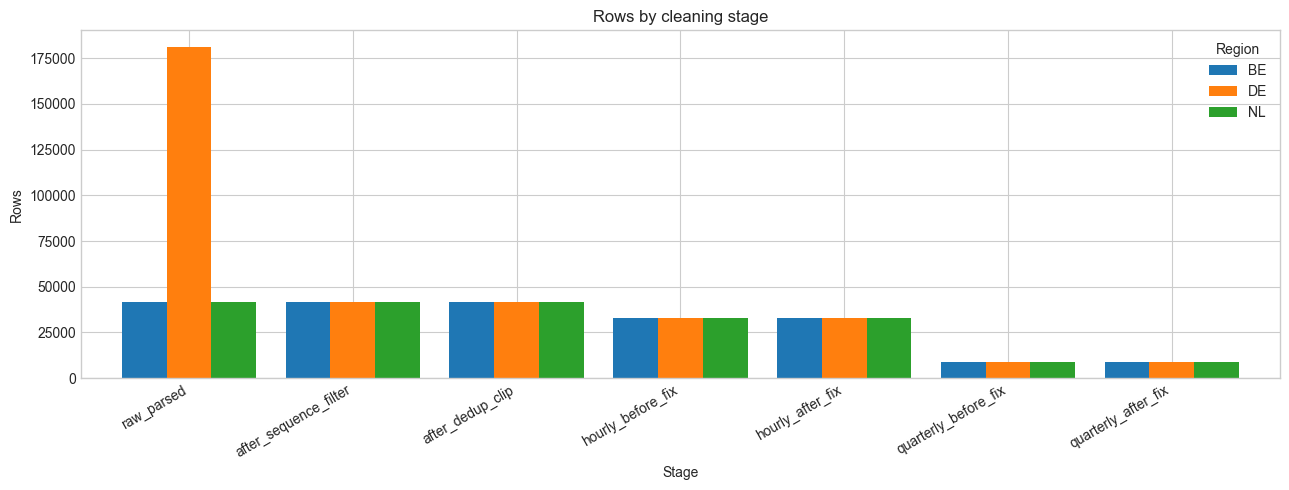

In [12]:
plot_stage_row_counts(stage_summary_df)


## 3. Upstream Missing-Datapoint Fix

The new fix works on the canonical UTC grid for each final dataset:

- single and double missing datapoints are linearly interpolated between the closest known values
- runs longer than two datapoints are left missing and flagged
- DST is not treated as a missing-data source because the raw timestamps are already UTC


In [13]:
display(gap_fix_summary_df)


,region,dataset,expected_step_minutes,rows_before_fix,rows_after_fix,missing_datapoints_before_fix,missing_timestamps_before_fix,missing_values_before_fix,interpolated_points_count,flagged_gap_groups_count,flagged_gap_points_count,flagged_long_gap_groups_count,flagged_long_gap_points_count,flagged_unbounded_gap_groups_count,flagged_unbounded_gap_points_count,flagged_dst_gap_groups_count,remaining_missing_points_after_fix
0,BE,hourly,60,32707,32831,124,124,0,108,3,16,3,16,0,0,0,16
1,DE,hourly,60,32702,32855,153,153,0,137,3,16,3,16,0,0,0,16
2,NL,hourly,60,32660,32855,195,195,0,176,4,19,4,19,0,0,0,19
3,BE,quarterly,15,8814,8841,27,27,0,24,1,3,1,3,0,0,0,3
4,DE,quarterly,15,8785,8841,56,56,0,53,1,3,1,3,0,0,0,3
5,NL,quarterly,15,8792,8841,49,49,0,49,0,0,0,0,0,0,0,0


In [14]:
if gap_fix_details_df.empty:
    display(Markdown("**Gap detail rows:** none"))
else:
    gap_action_summary = (
        gap_fix_details_df.groupby(["region", "dataset", "action"], as_index=False)
        .agg(
            gap_runs=("gap_run_id", "count"),
            datapoints=("gap_length_points", "sum"),
            max_gap_length=("gap_length_points", "max"),
        )
        .sort_values(["dataset", "region", "action"])
        .reset_index(drop=True)
    )
    display(gap_action_summary)
    display(gap_fix_details_df.head(20))


,region,dataset,action,gap_runs,datapoints,max_gap_length
0,BE,hourly,flag_long_gap,3,16,7
1,BE,hourly,interpolate,100,108,2
2,DE,hourly,flag_long_gap,3,16,7
3,DE,hourly,interpolate,127,137,2
4,NL,hourly,flag_long_gap,4,19,7
5,NL,hourly,interpolate,162,176,2
6,BE,quarterly,flag_long_gap,1,3,3
7,BE,quarterly,interpolate,23,24,2
8,DE,quarterly,flag_long_gap,1,3,3
9,DE,quarterly,interpolate,48,53,2


,region,dataset,expected_step_minutes,gap_run_id,gap_start_utc,gap_end_utc,gap_start_local,gap_end_local,gap_length_points,missing_timestamps_in_gap,missing_values_in_gap,missing_datapoint_sources,is_bounded,previous_known_timestamp_utc,next_known_timestamp_utc,previous_known_price,next_known_price,dst_artifact,dst_note,action
0,BE,hourly,60,1,2022-01-13T17:00:00+00:00,2022-01-13T17:00:00+00:00,2022-01-13T18:00:00+01:00,2022-01-13T18:00:00+01:00,1,1,0,missing_timestamp,True,2022-01-13T16:00:00+00:00,2022-01-13T18:00:00+00:00,267.30,250.00,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
1,BE,hourly,60,2,2022-02-14T18:00:00+00:00,2022-02-14T18:00:00+00:00,2022-02-14T19:00:00+01:00,2022-02-14T19:00:00+01:00,1,1,0,missing_timestamp,True,2022-02-14T17:00:00+00:00,2022-02-14T19:00:00+00:00,235.73,202.21,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
2,BE,hourly,60,3,2022-02-25T08:00:00+00:00,2022-02-25T08:00:00+00:00,2022-02-25T09:00:00+01:00,2022-02-25T09:00:00+01:00,1,1,0,missing_timestamp,True,2022-02-25T07:00:00+00:00,2022-02-25T09:00:00+00:00,236.10,150.00,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
3,BE,hourly,60,4,2022-02-27T19:00:00+00:00,2022-02-27T19:00:00+00:00,2022-02-27T20:00:00+01:00,2022-02-27T20:00:00+01:00,1,1,0,missing_timestamp,True,2022-02-27T18:00:00+00:00,2022-02-27T20:00:00+00:00,283.35,220.82,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
4,BE,hourly,60,5,2022-03-04T18:00:00+00:00,2022-03-04T18:00:00+00:00,2022-03-04T19:00:00+01:00,2022-03-04T19:00:00+01:00,1,1,0,missing_timestamp,True,2022-03-04T17:00:00+00:00,2022-03-04T19:00:00+00:00,410.00,400.08,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
5,BE,hourly,60,6,2022-03-06T21:00:00+00:00,2022-03-06T21:00:00+00:00,2022-03-06T22:00:00+01:00,2022-03-06T22:00:00+01:00,1,1,0,missing_timestamp,True,2022-03-06T20:00:00+00:00,2022-03-06T22:00:00+00:00,412.02,411.65,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
6,BE,hourly,60,7,2022-03-08T01:00:00+00:00,2022-03-08T01:00:00+00:00,2022-03-08T02:00:00+01:00,2022-03-08T02:00:00+01:00,1,1,0,missing_timestamp,True,2022-03-08T00:00:00+00:00,2022-03-08T02:00:00+00:00,449.50,424.88,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
7,BE,hourly,60,8,2022-03-09T03:00:00+00:00,2022-03-09T03:00:00+00:00,2022-03-09T04:00:00+01:00,2022-03-09T04:00:00+01:00,1,1,0,missing_timestamp,True,2022-03-09T02:00:00+00:00,2022-03-09T04:00:00+00:00,420.03,440.00,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
8,BE,hourly,60,9,2022-03-13T12:00:00+00:00,2022-03-13T13:00:00+00:00,2022-03-13T13:00:00+01:00,2022-03-13T14:00:00+01:00,2,2,0,missing_timestamp,True,2022-03-13T11:00:00+00:00,2022-03-13T14:00:00+00:00,-40.00,-20.00,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate
9,BE,hourly,60,10,2022-04-01T11:00:00+00:00,2022-04-01T11:00:00+00:00,2022-04-01T13:00:00+02:00,2022-04-01T13:00:00+02:00,1,1,0,missing_timestamp,True,2022-04-01T10:00:00+00:00,2022-04-01T12:00:00+00:00,185.00,192.00,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",interpolate


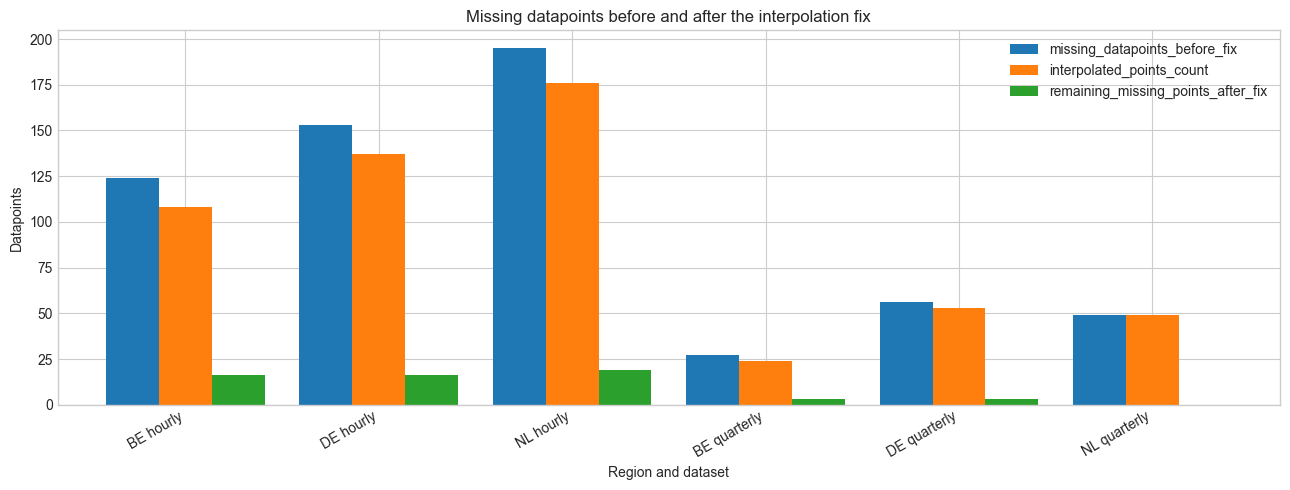

In [15]:
plot_gap_fix_summary(gap_fix_summary_df)


## 4. Focus Region Examples

The examples below use the selected focus region so you can inspect actual interpolated rows and longer flagged gaps directly in the time series.


In [16]:
focus_result = region_results[FOCUS_REGION]

focus_hourly_changes = focus_result["hourly_final"][
    focus_result["hourly_final"]["gap_fix_action"] != "observed"
][
    [
        "timestamp_utc",
        "price_eur_per_mwh",
        "price_eur_per_mwh_original",
        "missing_datapoint_source",
        "gap_fix_action",
    ]
].head(20)

focus_quarterly_changes = focus_result["quarterly_final"][
    focus_result["quarterly_final"]["gap_fix_action"] != "observed"
][
    [
        "timestamp_utc",
        "price_eur_per_mwh",
        "price_eur_per_mwh_original",
        "missing_datapoint_source",
        "gap_fix_action",
    ]
].head(20)

display(Markdown(f"**{FOCUS_REGION} hourly changed rows**"))
display(focus_hourly_changes)
display(Markdown(f"**{FOCUS_REGION} quarterly changed rows**"))
display(focus_quarterly_changes)


**NL hourly changed rows**

,timestamp_utc,price_eur_per_mwh,price_eur_per_mwh_original,missing_datapoint_source,gap_fix_action
1,2022-01-01 00:00:00+00:00,129.350000,NaN,missing_timestamp,interpolate
307,2022-01-13 18:00:00+00:00,190.500000,NaN,missing_timestamp,interpolate
308,2022-01-13 19:00:00+00:00,188.700000,NaN,missing_timestamp,interpolate
376,2022-01-16 15:00:00+00:00,229.500000,NaN,missing_timestamp,interpolate
398,2022-01-17 13:00:00+00:00,219.500000,NaN,missing_timestamp,interpolate
481,2022-01-21 00:00:00+00:00,150.250000,NaN,missing_timestamp,interpolate
483,2022-01-21 02:00:00+00:00,155.300000,NaN,missing_timestamp,interpolate
742,2022-01-31 21:00:00+00:00,200.650000,NaN,missing_timestamp,interpolate
1035,2022-02-13 02:00:00+00:00,155.210000,NaN,missing_timestamp,interpolate
1163,2022-02-18 10:00:00+00:00,157.350000,NaN,missing_timestamp,interpolate


**NL quarterly changed rows**

,timestamp_utc,price_eur_per_mwh,price_eur_per_mwh_original,missing_datapoint_source,gap_fix_action
110,2025-10-02 01:30:00+00:00,78.160000,NaN,missing_timestamp,interpolate
306,2025-10-04 02:30:00+00:00,-4.243333,NaN,missing_timestamp,interpolate
307,2025-10-04 02:45:00+00:00,-4.446667,NaN,missing_timestamp,interpolate
395,2025-10-05 00:45:00+00:00,-4.070000,NaN,missing_timestamp,interpolate
405,2025-10-05 03:15:00+00:00,-4.050000,NaN,missing_timestamp,interpolate
407,2025-10-05 03:45:00+00:00,-4.035000,NaN,missing_timestamp,interpolate
429,2025-10-05 09:15:00+00:00,-2.015000,NaN,missing_timestamp,interpolate
991,2025-10-11 05:45:00+00:00,100.790000,NaN,missing_timestamp,interpolate
2185,2025-10-23 16:15:00+00:00,112.120000,NaN,missing_timestamp,interpolate
2191,2025-10-23 17:45:00+00:00,131.560000,NaN,missing_timestamp,interpolate


In [17]:
display(
    gap_fix_details_df[
        (gap_fix_details_df["region"] == FOCUS_REGION)
        & (gap_fix_details_df["action"] != "interpolate")
    ].head(20)
)


,region,dataset,expected_step_minutes,gap_run_id,gap_start_utc,gap_end_utc,gap_start_local,gap_end_local,gap_length_points,missing_timestamps_in_gap,missing_values_in_gap,missing_datapoint_sources,is_bounded,previous_known_timestamp_utc,next_known_timestamp_utc,previous_known_price,next_known_price,dst_artifact,dst_note,action
330,NL,hourly,60,98,2024-03-24T08:00:00+00:00,2024-03-24T14:00:00+00:00,2024-03-24T09:00:00+01:00,2024-03-24T15:00:00+01:00,7,7,0,missing_timestamp,True,2024-03-24T07:00:00+00:00,2024-03-24T15:00:00+00:00,0.0,11.60,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",flag_long_gap
332,NL,hourly,60,100,2024-04-07T01:00:00+00:00,2024-04-07T06:00:00+00:00,2024-04-07T03:00:00+02:00,2024-04-07T08:00:00+02:00,6,6,0,missing_timestamp,True,2024-04-07T00:00:00+00:00,2024-04-07T07:00:00+00:00,0.0,-0.01,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",flag_long_gap
370,NL,hourly,60,138,2025-04-27T00:00:00+00:00,2025-04-27T02:00:00+00:00,2025-04-27T02:00:00+02:00,2025-04-27T04:00:00+02:00,3,3,0,missing_timestamp,True,2025-04-26T23:00:00+00:00,2025-04-27T03:00:00+00:00,95.6,85.00,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",flag_long_gap
382,NL,hourly,60,150,2025-07-13T11:00:00+00:00,2025-07-13T13:00:00+00:00,2025-07-13T13:00:00+02:00,2025-07-13T15:00:00+02:00,3,3,0,missing_timestamp,True,2025-07-13T10:00:00+00:00,2025-07-13T14:00:00+00:00,0.0,2.59,False,"Source timestamps are stored in UTC, so DST does not create missing UTC datapoints.",flag_long_gap


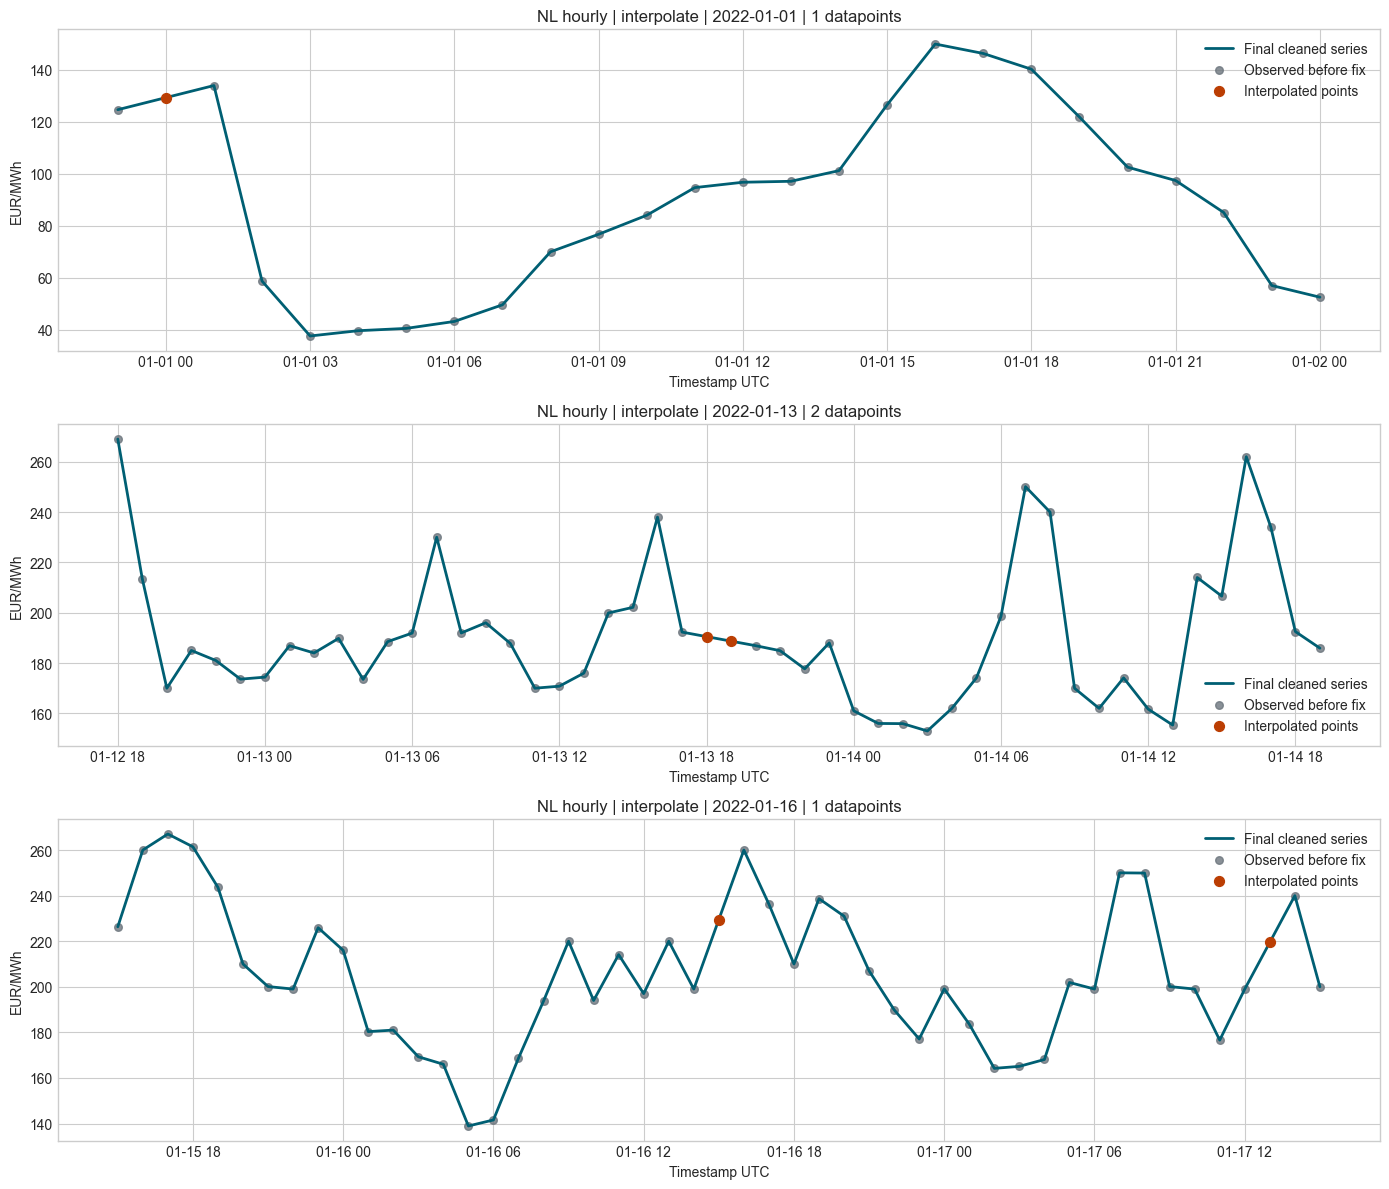

In [18]:
plot_gap_windows(focus_result, dataset="hourly", action="interpolate", max_windows=3)


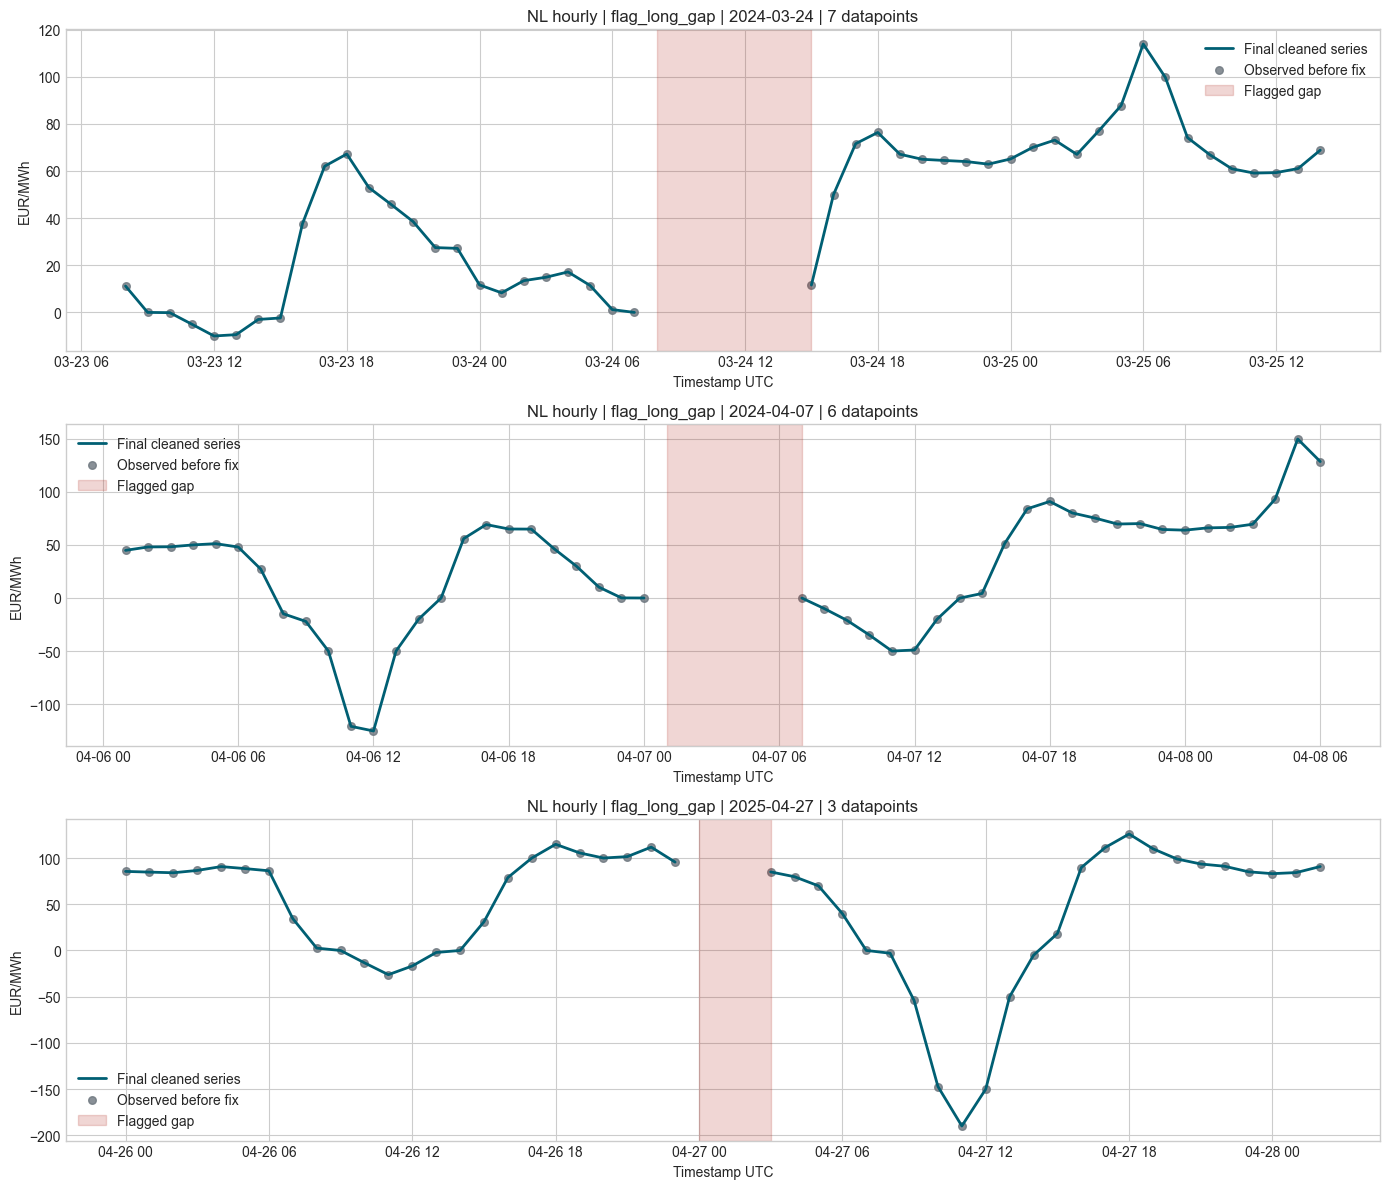

In [19]:
plot_gap_windows(focus_result, dataset="hourly", action="flag_long_gap", max_windows=3)


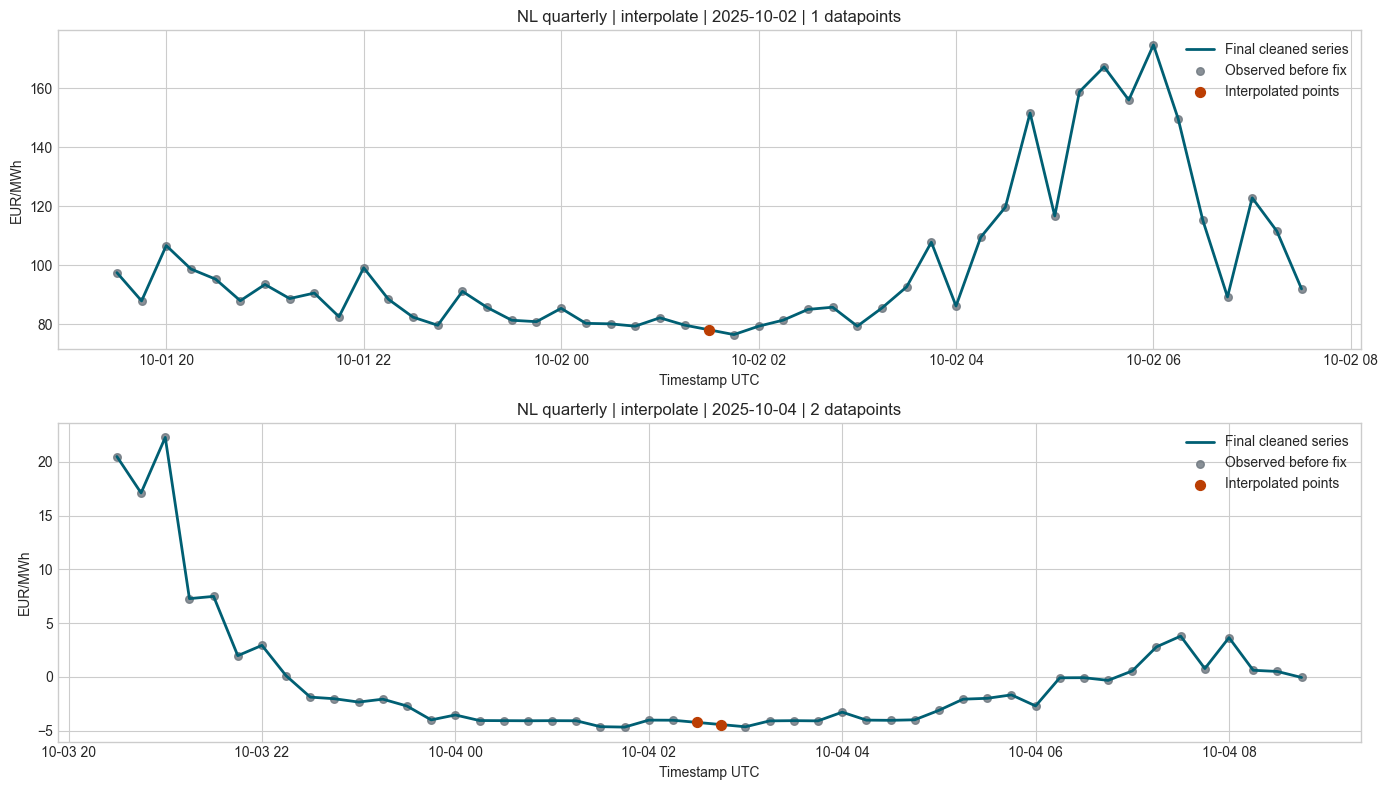

In [20]:
plot_gap_windows(focus_result, dataset="quarterly", action="interpolate", max_windows=2)


## 5. Final Cleaned Outputs and Summary

The final tables below summarize the cleaned outputs that would be written by the shared pipeline, including the pre-fix gap counts, the interpolation counts, and the remaining flagged missing datapoints.


In [21]:
display(final_diagnostics_df)


,record_type,dataset,region,rows,min_timestamp_utc,max_timestamp_utc,dominant_step_minutes,missing_timestamps_count,offgrid_count,duplicate_rows_removed,sequence_2_rows_removed,missing_price_points_count,missing_datapoints_before_fix,missing_timestamps_before_fix,missing_values_before_fix,interpolated_points_count,flagged_gap_groups_count,flagged_gap_points_count,flagged_long_gap_groups_count,flagged_long_gap_points_count,flagged_unbounded_gap_groups_count,flagged_unbounded_gap_points_count,remaining_missing_points_after_fix,mean_price,std_price,min_price,max_price,negative_price_count,resolution_distribution,union_timestamp_count,intersection_timestamp_count,missing_vs_union_json
0,region,aggregated,BE,41696,2021-12-31T23:00:00+00:00,2026-01-01T00:00:00+00:00,60,0,0,72,0,19,0,0,0,0,0,0,0,0,0,0,19,117.086534,98.532739,-462.33,871.00,1349,"{""15"": 8865, ""60"": 32831}",None,None,None
1,region,aggregated,DE,41696,2021-12-31T23:00:00+00:00,2026-01-01T00:00:00+00:00,60,0,0,68,139435,19,0,0,0,0,0,0,0,0,0,0,19,119.630541,99.308560,-500.00,936.28,1552,"{""15"": 8841, ""60"": 32855}",None,None,None
2,region,aggregated,NL,41696,2021-12-31T23:00:00+00:00,2026-01-01T00:00:00+00:00,60,0,0,69,0,19,0,0,0,0,0,0,0,0,0,0,19,119.514163,97.211142,-500.00,872.96,1565,"{""15"": 8841, ""60"": 32855}",None,None,None
3,region,hourly,BE,32831,2021-12-31T23:00:00+00:00,2025-09-29T21:00:00+00:00,60,124,0,0,0,16,124,124,0,108,3,16,3,16,0,0,16,126.506847,107.681935,-462.33,871.00,1220,"{""60"": 32831}",None,None,None
4,region,hourly,DE,32855,2021-12-31T23:00:00+00:00,2025-09-30T21:00:00+00:00,60,153,0,0,0,16,153,153,0,137,3,16,3,16,0,0,16,126.753061,108.198629,-500.00,936.28,1347,"{""60"": 32855}",None,None,None
5,region,hourly,NL,32855,2021-12-31T23:00:00+00:00,2025-09-30T21:00:00+00:00,60,195,0,0,0,19,195,195,0,176,4,19,4,19,0,0,19,128.038337,105.951210,-500.00,872.96,1391,"{""60"": 32855}",None,None,None
6,region,quarterly,BE,8841,2025-09-30T22:00:00+00:00,2026-01-01T00:00:00+00:00,15,27,0,0,0,3,27,27,0,24,1,3,1,3,0,0,3,82.159736,34.300235,-6.90,340.79,129,"{""15"": 8841}",None,None,None
7,region,quarterly,DE,8841,2025-09-30T22:00:00+00:00,2026-01-01T00:00:00+00:00,15,56,0,0,0,3,56,56,0,53,1,3,1,3,0,0,3,93.165683,46.035619,-5.09,508.38,205,"{""15"": 8841}",None,None,None
8,region,quarterly,NL,8841,2025-09-30T22:00:00+00:00,2026-01-01T00:00:00+00:00,15,49,0,0,0,0,49,49,0,49,0,0,0,0,0,0,0,87.854875,39.791034,-8.79,437.97,174,"{""15"": 8841}",None,None,None


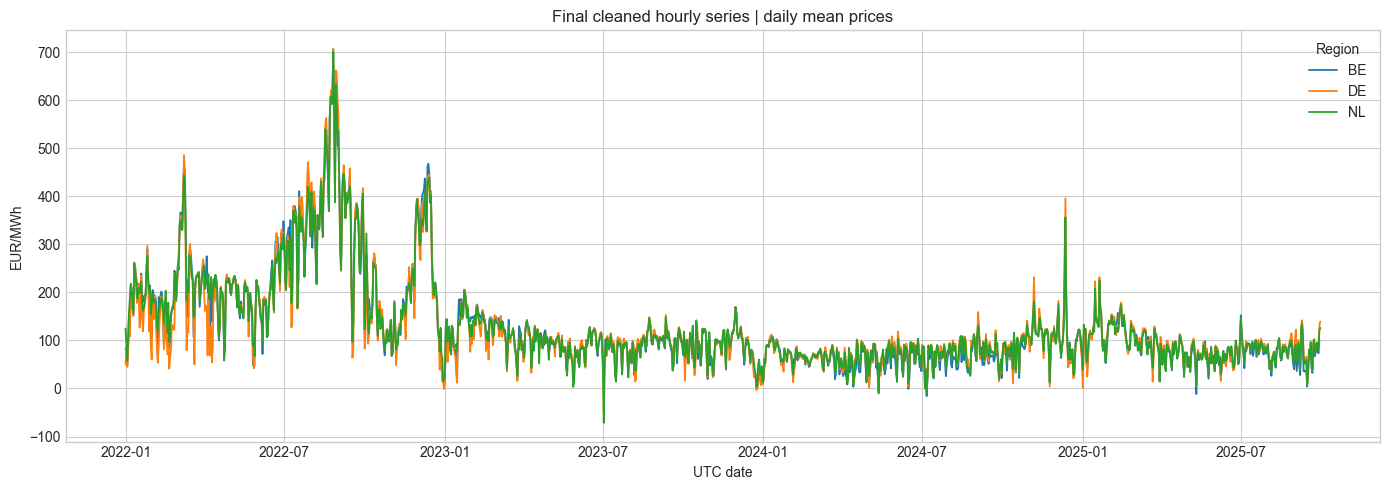

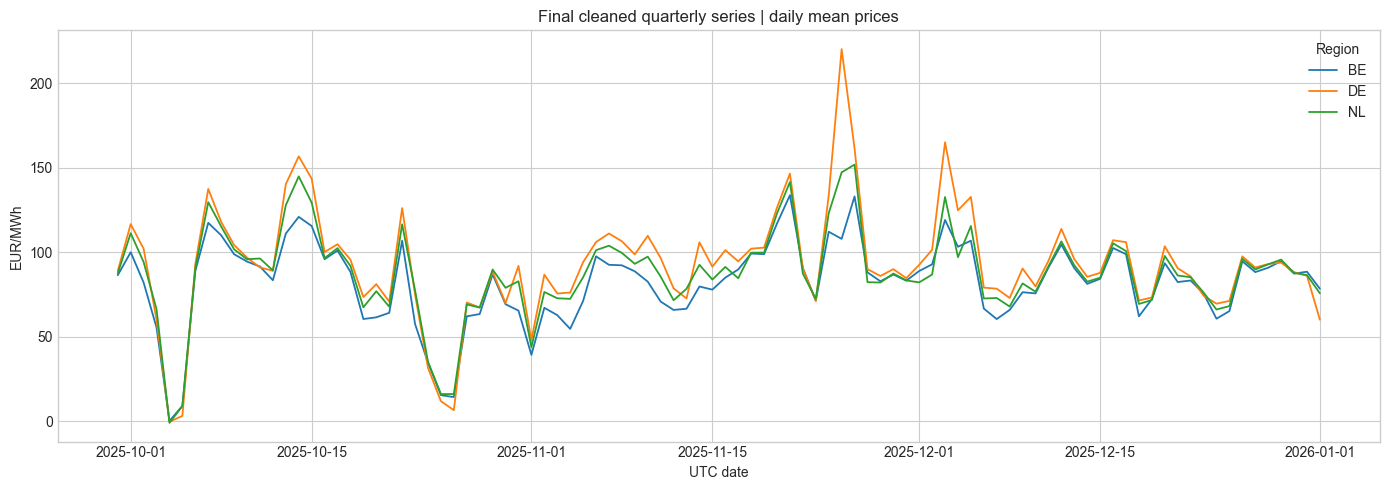

In [22]:
plot_daily_means(region_results, dataset="hourly")
plot_daily_means(region_results, dataset="quarterly")


In [23]:
summary_view = gap_fix_summary_df[
    [
        "region",
        "dataset",
        "missing_datapoints_before_fix",
        "interpolated_points_count",
        "flagged_long_gap_points_count",
        "flagged_unbounded_gap_points_count",
        "remaining_missing_points_after_fix",
    ]
].copy()
display(summary_view)

summary_lines = []
for row in summary_view.itertuples(index=False):
    summary_lines.append(
        f"- {row.region} {row.dataset}: "
        f"{row.interpolated_points_count} interpolated, "
        f"{row.remaining_missing_points_after_fix} remaining missing, "
        f"{row.flagged_long_gap_points_count} in long flagged runs."
    )

display(Markdown("### Notebook summary\n" + "\n".join(summary_lines)))


,region,dataset,missing_datapoints_before_fix,interpolated_points_count,flagged_long_gap_points_count,flagged_unbounded_gap_points_count,remaining_missing_points_after_fix
0,BE,hourly,124,108,16,0,16
1,DE,hourly,153,137,16,0,16
2,NL,hourly,195,176,19,0,19
3,BE,quarterly,27,24,3,0,3
4,DE,quarterly,56,53,3,0,3
5,NL,quarterly,49,49,0,0,0


### Notebook summary
- BE hourly: 108 interpolated, 16 remaining missing, 16 in long flagged runs.
- DE hourly: 137 interpolated, 16 remaining missing, 16 in long flagged runs.
- NL hourly: 176 interpolated, 19 remaining missing, 19 in long flagged runs.
- BE quarterly: 24 interpolated, 3 remaining missing, 3 in long flagged runs.
- DE quarterly: 53 interpolated, 3 remaining missing, 3 in long flagged runs.
- NL quarterly: 49 interpolated, 0 remaining missing, 0 in long flagged runs.